<a href="https://colab.research.google.com/github/valanchick/Dynamic-Real-Estate-Pricing/blob/main/Smart_Pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/AB_NYC_2019.csv'
df = pd.read_csv(url)

print(f"Размер исходных данных: {df.shape[0]} строк и {df.shape[1]} колонок.")
df.head(5)

Размер исходных данных: 48895 строк и 16 колонок.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_3951/944446942.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='room_type', y='price', data=df_viz, ax=ax2, palette='Set2', inner='quartile')
/tmp/ipykernel_3951/944446942.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood_group', y='price', data=df_viz, ax=ax3, palette='pastel')
/tmp/ipykernel_3951/944446942.py:34: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_viz_reviews = df_viz[df['number_of_reviews']>0].copy()
/usr/local/lib/python3.12/d

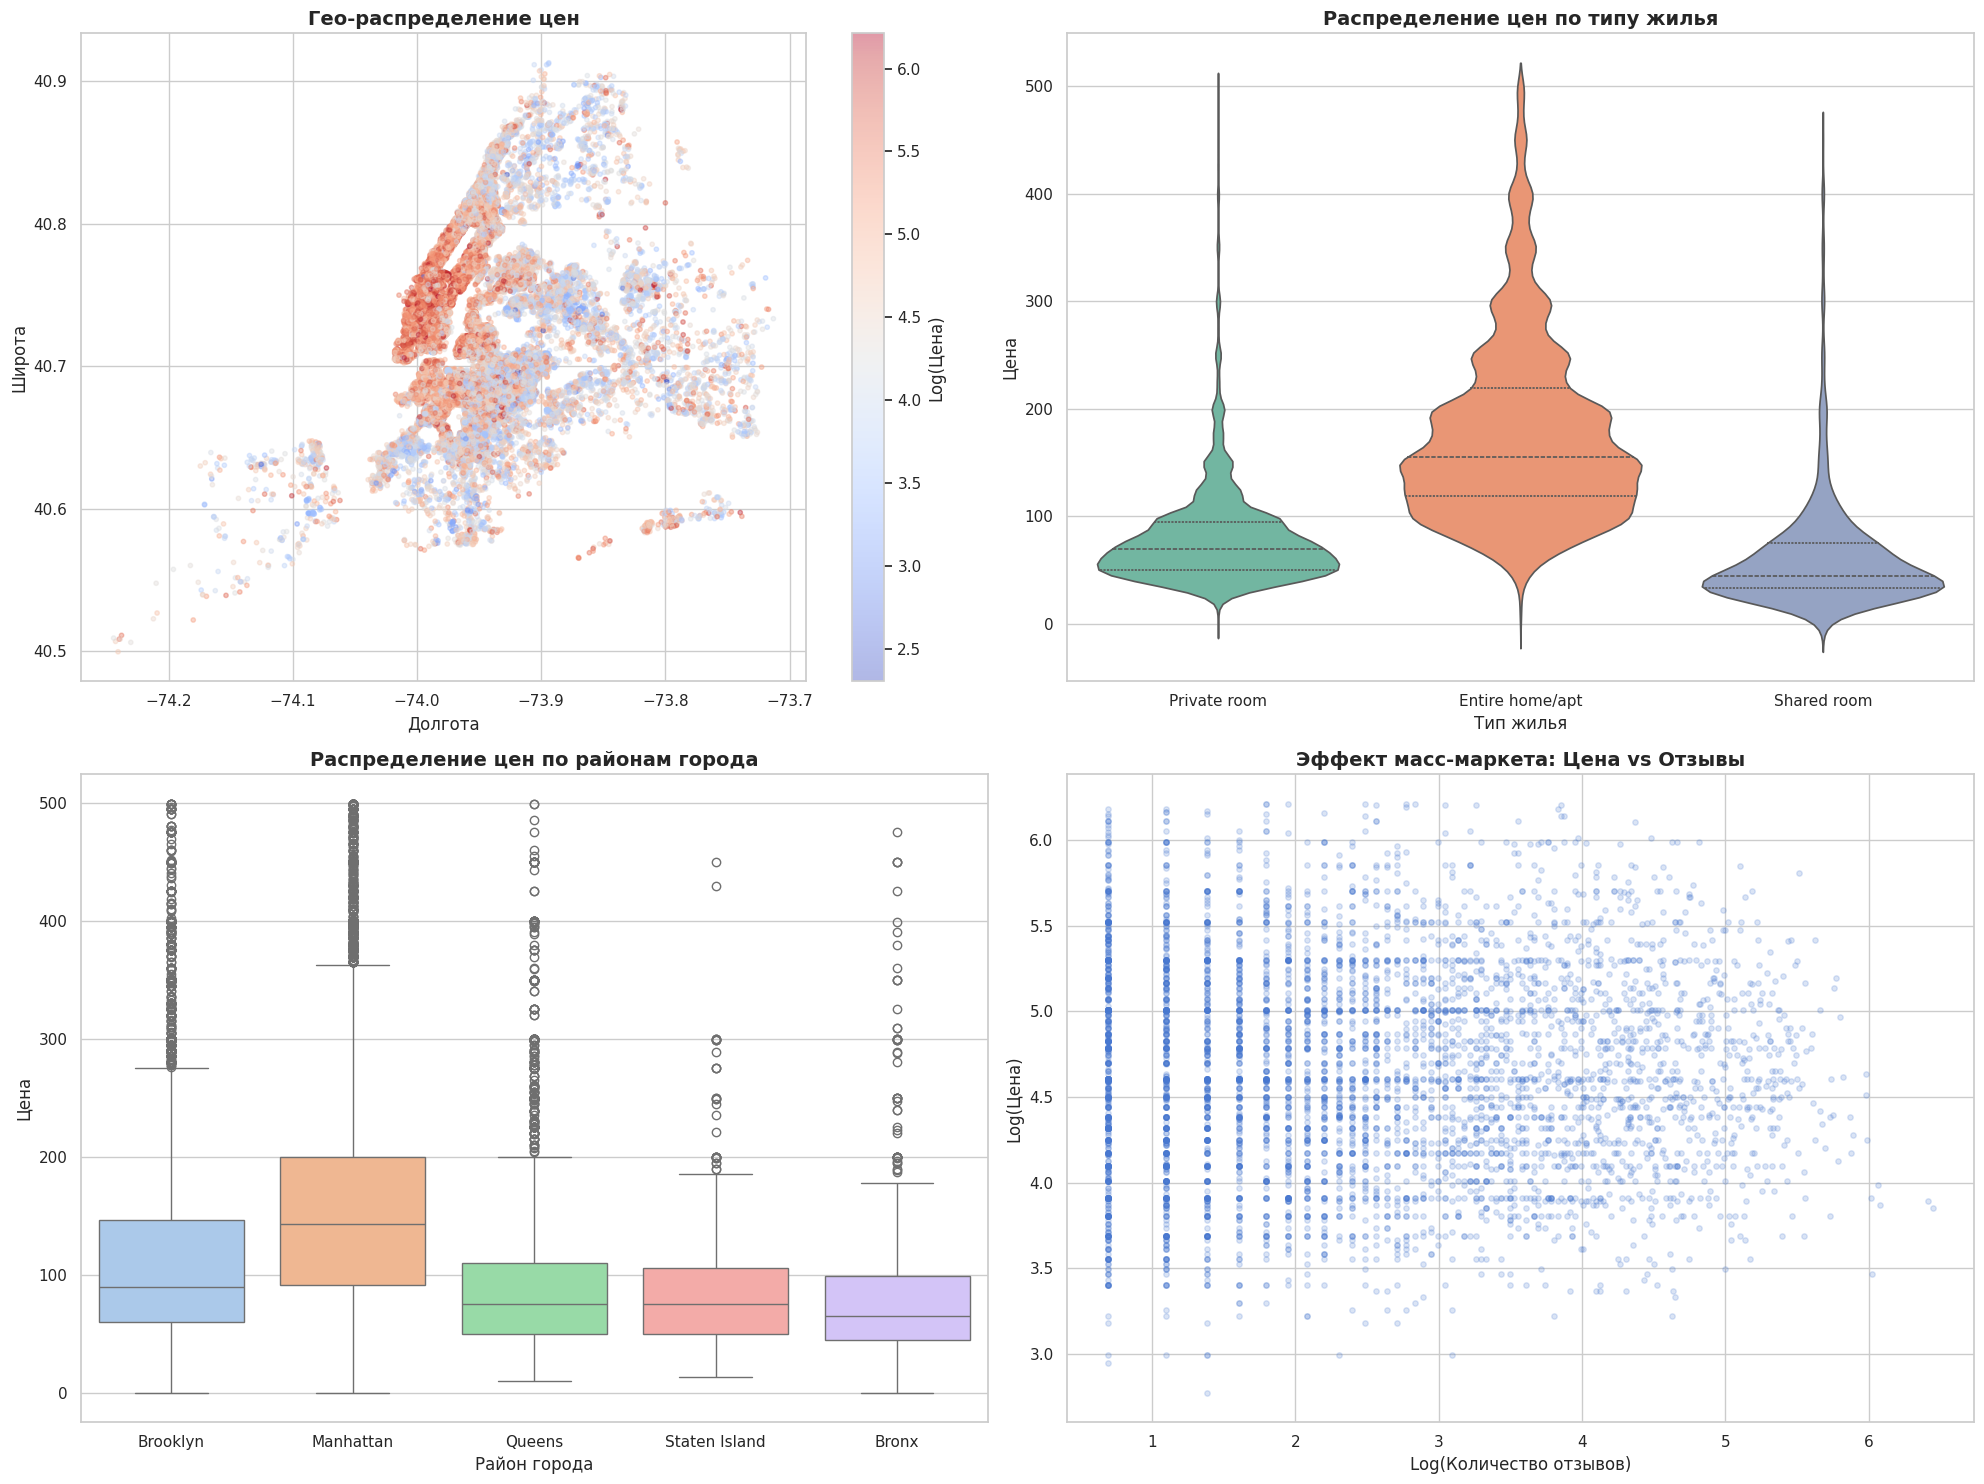

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

df_viz = df[df['price']<500].copy()
df_viz['price_log'] = np.log(df_viz['price'])

fig = plt.figure(figsize = (20, 15))

ax1 = plt.subplot(2, 2, 1)
scatter = ax1.scatter(df_viz['longitude'], df_viz['latitude'],
                      c = df_viz['price_log'], cmap = 'coolwarm',
                      alpha=0.4, s = 10)
plt.colorbar(scatter, ax=ax1, label='Log(Цена)')
ax1.set_title('Гео-распределение цен', fontsize=14, fontweight='bold')
ax1.set_xlabel('Долгота')
ax1.set_ylabel('Широта')

ax2 = plt.subplot(2, 2, 2)
sns.violinplot(x='room_type', y='price', data=df_viz, ax=ax2, palette='Set2', inner='quartile')
ax2.set_title('Распределение цен по типу жилья', fontsize=14, fontweight='bold')
ax2.set_xlabel('Тип жилья')
ax2.set_ylabel('Цена')

ax3 = plt.subplot(2, 2, 3)
sns.boxplot(x='neighbourhood_group', y='price', data=df_viz, ax=ax3, palette='pastel')
ax3.set_title('Распределение цен по районам города', fontsize=14, fontweight='bold')
ax3.set_xlabel('Район города')
ax3.set_ylabel('Цена')

ax4 = plt.subplot(2, 2, 4)
df_viz_reviews = df_viz[df['number_of_reviews']>0].copy()
df_viz_reviews['log_reviews'] = np.log1p(df_viz_reviews['number_of_reviews'])
sns.regplot(x='log_reviews', y='price_log', data=df_viz_reviews.sample(5000), scatter_kws={'alpha':0.2, 's':15}, line_kws={'color':'red'}, ax=ax4)
ax4.set_title('Эффект масс-маркета: Цена vs Отзывы', fontsize=14, fontweight='bold')
ax4.set_xlabel('Log(Количество отзывов)')
ax4.set_ylabel('Log(Цена)')

plt.tight_layout()
plt.show()

**Гео-распределение цен:**                    
На графике чётко вырисовываются контуры Нью-Йорка (отчётливо виден плотный Манхэттен и контуры Бруклина). Красные точки (высокая цена) сконцентрированы в центре Манхэттена и вдоль береговой линии Ист-Ривер. Синие точки (бюджетное жильё) разбросаны по окраинам. Координаты несут огромную предиктивную силу. Но деревьям тяжело работать с сырыми широтой и долготой, поэтому мы рассчитаем расстояние до центра Нью-Йорка.                    
**Распределение по типу жилья:**                        
Entire home/apt имеют самую высокую медиану и самый длинный "хвост" выбросов вверх. Shared room - самый бюджетный сегмент с минимальной дисперсией. Признак room_type несёт огромную важность в ценообразовании. Длинный "хвост" подтверждает необходимость использования логарифмирования таргета, применения робастной к выбросам функции потерь MAE при обучении модели.               
**Макро-районы:**                      
Манхэттен - абсолютный лидер по стоимости, его "ящик" находится выше медиан почти всех остальных районов. Бронкс - самый дешёвый район.              
**Зависимость цены от популярности объекта:**     
Линия линейного тренда имеет отрицательный наклон. Чем больше у квартиры отзывов, чем ниже её цена. Модель будет использовать этот признак, чтобы понижать предсказанную цену для объектов с сотнями отзывов, понимаю, что это сегмент масс-маркета.        

In [3]:
import pandas as pd
import numpy as np

def missing_values_report(data):
  total_missing = data.isnull().sum()
  percent_missing = (data.isnull().sum()/len(data))*100
  unique_values = data.nunique()
  missing_data = pd.DataFrame({
      'Тип данных': data.dtypes,
      'Количетсво пропусков': total_missing,
      'Процент пропусков': percent_missing.round(2),
      'Уникальные значения': unique_values
  })

  return missing_data.sort_values(by='Процент пропусков', ascending=True)

display(missing_values_report(df))



,Тип данных,Количетсво пропусков,Процент пропусков,Уникальные значения
id,int64,0,0.00,48895
host_id,int64,0,0.00,37457
neighbourhood,object,0,0.00,221
neighbourhood_group,object,0,0.00,5
latitude,float64,0,0.00,19048
longitude,float64,0,0.00,14718
price,int64,0,0.00,674
room_type,object,0,0.00,3
availability_365,int64,0,0.00,366
calculated_host_listings_count,int64,0,0.00,47


In [4]:
from scipy import stats
import numpy as np

df_stat = df[df['price']>0].copy()

room_groups =[group.values for _, group in df_stat.groupby('room_type')['price']]
stat_kw, p_kw = stats.kruskal(*room_groups)
print(f"H-статистика: {stat_kw:.2f} | P-value: {p_kw:.2e}")
if p_kw < 0.05:
    print("Вывод: Отвергаем нулевую гипотезу. Тип жилья СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на цену.")
else:
    print("Вывод: Разница в ценах случайна.")

boroughs = df_stat[df_stat['neighbourhood_group'].isin(['Manhattan', 'Brooklyn'])]
grouped_prices = {name: group.values for name, group in boroughs.groupby('neighbourhood_group')['price']}
manhattan_prices = grouped_prices['Manhattan']
brooklyn_prices = grouped_prices['Brooklyn']
stat_mw, p_mw = stats.mannwhitneyu(manhattan_prices, brooklyn_prices, alternative='greater')
if p_mw < 0.05:
    print("Вывод: Отвергаем нулевую гипотезу. Манхэттен СТАТИСТИЧЕСКИ ЗНАЧИМО дороже Бруклина.")
else:
    print("Вывод: Манхэттен не дороже Бруклина.")

corr_coef, p_spearman = stats.spearmanr(df_stat['number_of_reviews'], df_stat['price'])
print(f"Коэффициент корреляции: {corr_coef:.3f} | P-value: {p_spearman:.2e}")
if p_spearman < 0.05:
    print("Вывод: Связь СТАТИСТИЧЕСКИ ЗНАЧИМА.")
    if corr_coef < 0:
        print("Характер связи: ОБРАТНАЯ. Чем больше отзывов, тем НИЖЕ цена (эффект бюджетного жилья).")
    else:
        print("Характер связи: ПРЯМАЯ. Чем больше отзывов, тем ВЫШЕ цена.")
else:
    print("Вывод: Статистически значимой связи нет.")


H-статистика: 22414.84 | P-value: 0.00e+00
Вывод: Отвергаем нулевую гипотезу. Тип жилья СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на цену.
Вывод: Отвергаем нулевую гипотезу. Манхэттен СТАТИСТИЧЕСКИ ЗНАЧИМО дороже Бруклина.
Коэффициент корреляции: -0.055 | P-value: 5.98e-34
Вывод: Связь СТАТИСТИЧЕСКИ ЗНАЧИМА.
Характер связи: ОБРАТНАЯ. Чем больше отзывов, тем НИЖЕ цена (эффект бюджетного жилья).


/tmp/ipykernel_3243/2564422274.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood', y='price', data=df_top_15, order=order, palette='magma')


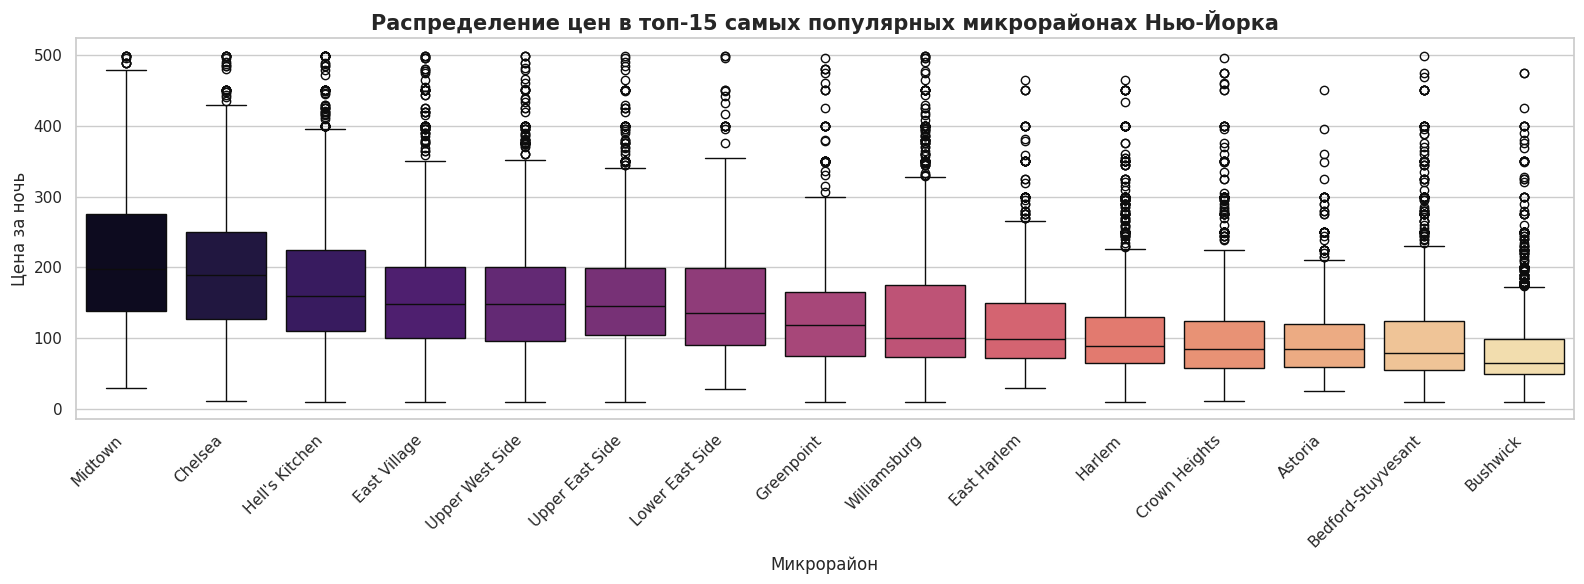

Количество анализируемых микрорайонов: 167
H-статистика: 14555.47 | P-value: 0.00e+00
Вывод: Отвергаем нулевую гипотезу.
Микрорайон СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на цену квартиры.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

top_15_hoods = df_stat['neighbourhood'].value_counts().nlargest(15).index
df_top_15 = df_stat[(df_stat['neighbourhood'].isin(top_15_hoods)) & (df_stat['price']<500)]
order = df_top_15.groupby('neighbourhood')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 6))
sns.boxplot(x='neighbourhood', y='price', data=df_top_15, order=order, palette='magma')
plt.title('Распределение цен в топ-15 самых популярных микрорайонах Нью-Йорка', fontsize=15, fontweight='bold')
plt.xlabel('Микрорайон', fontsize=12)
plt.ylabel('Цена за ночь', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

hood_counts=df_stat['neighbourhood'].value_counts()
valid_hoods = hood_counts[hood_counts>=10].index
df_valid_hoods = df_stat[df_stat['neighbourhood'].isin(valid_hoods)]
hood_groups = [group.values for _,group in df_valid_hoods.groupby('neighbourhood')['price']]
stat_kw, p_kw = stats.kruskal(*hood_groups)
print(f"Количество анализируемых микрорайонов: {len(valid_hoods)}")
print(f"H-статистика: {stat_kw:.2f} | P-value: {p_kw:.2e}")
if p_kw < 0.05:
    print("Вывод: Отвергаем нулевую гипотезу.")
    print("Микрорайон СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на цену квартиры.")
else:
    print("Вывод: Разница в ценах между микрорайонами случайна.")

**Топ-15 популярных микрорайонов**         
График выстроен по убыванию медианной цены. Мы видим строгую иерархию: престижные районы Манхэттена стоят радикально дороже модных, но более отдалённых районов Бруклина. График показывает, что этот признак содержит сильный сигнал для модели, поэтому мы будем использовать для кодирования признака встроенный в CatBoost Target Encoding, так как OHE создаст огромное количество лишних колонок.

In [6]:
import pandas as pd
import numpy as np

df_prep = df.copy()
df_prep[df_prep['price']>0]

df_prep['name']=df_prep['name'].fillna('Unknown')
df_prep['host_name'] = df_prep['host_name'].fillna('Unknown')

df_prep['reviews_per_month'] = df_prep['reviews_per_month'].fillna(0)

In [7]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
  lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
  a = np.sin((lat2-lat1)/2.0)**2+np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2.0)**2
  return 6731*2*np.arcsin(np.sqrt(a))

In [8]:
center_lat, center_lon = 40.7580, -73.9855
df_prep['distance_to_center'] = haversine_vectorized(df_prep['latitude'], df['longitude'], center_lat, center_lon)

df_prep['last_review'] = pd.to_datetime(df_prep['last_review'])
current_date = df_prep['last_review'].max()
df_prep['days_since_last_review'] = (current_date-df_prep['last_review']).dt.days.fillna(3650).astype(int)

names_lower = df_prep['name'].str.lower()
df_prep['is_luxury'] = names_lower.str.contains('luxury|gotgeous|stunning').astype(int)
df_prep['is_cozy'] = names_lower.str.contains('cozy|comfy|warm').astype(int)
df_prep['is_spacious'] = names_lower.str.contains('spacious|huge|large').astype(int)
df_prep['has_view'] = names_lower.str.contains('view|skyline|rooftop').astype(int)

cols_to_drop=['id', 'host_id', 'host_name', 'last_review', 'latitude', 'longitude']
df_final = df_prep.drop(columns=cols_to_drop)
cat_features = ['neighbourhood_group', 'neighbourhood', 'room_type']
df_final[cat_features] = df_final[cat_features].astype(str)
text_features = ['name']
df_final[text_features] = df_final[text_features].astype(str)

print(f"Итоговый размер: {df_final.shape[0]} строк и {df_final.shape[1]} колонок.")
display(df_final.head(3))

Итоговый размер: 48895 строк и 16 колонок.


,name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,distance_to_center,days_since_last_review,is_luxury,is_cozy,is_spacious,has_view
0,Clean & quiet apt home by the park,Brooklyn,Kensington,Private room,149,1,9,0.21,6,365,13.035063,262,0,0,0,0
1,Skylit Midtown Castle,Manhattan,Midtown,Entire home/apt,225,1,45,0.38,2,355,0.537091,48,0,0,0,0
2,THE VILLAGE OF HARLEM....NEW YORK !,Manhattan,Harlem,Private room,150,3,0,0.00,1,365,7.139065,3650,0,0,0,0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

TARGET = 'price'
y = np.log1p(df_prep[TARGET])
X = df_final.drop(columns=TARGET)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

def get_segment_features(df_subset):
    seg_features = pd.DataFrame(index=df_subset.index)
    room_mapping = {'Shared room': 0, 'Private room': 1, 'Entire home/apt': 2}

    seg_features['room_rank'] = df_subset['room_type'].map(room_mapping).fillna(0)
    seg_features['is_lux'] = df_subset['is_luxury']
    seg_features['has_view'] = df_subset['has_view']
    seg_features['dist_center'] = df_subset['distance_to_center']
    return seg_features

X_train_seg = get_segment_features(X_train)
X_test_seg = get_segment_features(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_seg)
X_test_scaled = scaler.transform(X_test_seg)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
X_train['quality_segment'] = kmeans.fit_predict(X_train_scaled)
X_test['quality_segment'] = kmeans.predict(X_test_scaled)

X_train['quality_segment'] = X_train['quality_segment'].astype(str)
X_test['quality_segment'] = X_test['quality_segment'].astype(str)

display(X_train[['room_type', 'is_luxury', 'distance_to_center', 'quality_segment']].head())

Train size: 39116 | Test size: 9779


,room_type,is_luxury,distance_to_center,quality_segment
32645,Entire home/apt,0,5.642623,3
23615,Private room,0,11.434238,0
31183,Private room,0,8.325780,0
29260,Entire home/apt,0,9.920455,3
7275,Private room,0,8.099796,0


In [10]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


Training on fold [0/3]

bestTest = 0.2990574362
bestIteration = 399

Training on fold [1/3]

bestTest = 0.2951683253
bestIteration = 399

Training on fold [2/3]

bestTest = 0.2973791631
bestIteration = 399

Training on fold [0/3]

bestTest = 0.2945543526
bestIteration = 399

Training on fold [1/3]

bestTest = 0.2904020288
bestIteration = 399

Training on fold [2/3]

bestTest = 0.2919687225
bestIteration = 399

Training on fold [0/3]

bestTest = 0.2960484724
bestIteration = 599

Training on fold [1/3]

bestTest = 0.2918098789
bestIteration = 599

Training on fold [2/3]

bestTest = 0.2942535696
bestIteration = 598

Training on fold [0/3]

bestTest = 0.2925238694
bestIteration = 599

Training on fold [1/3]

bestTest = 0.2882397098
bestIteration = 598

Training on fold [2/3]

bestTest = 0.2902365381
bestIteration = 599

Training on fold [0/3]

bestTest = 0.2960823448
bestIteration = 399

Training on fold [1/3]

bestTest = 0.291500589
bestIteration = 399

Training on fold [2/3]

bestTest = 

/tmp/ipykernel_3243/1660291044.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance[sorted_idx], y=np.array(X_train.columns)[sorted_idx], palette="viridis")


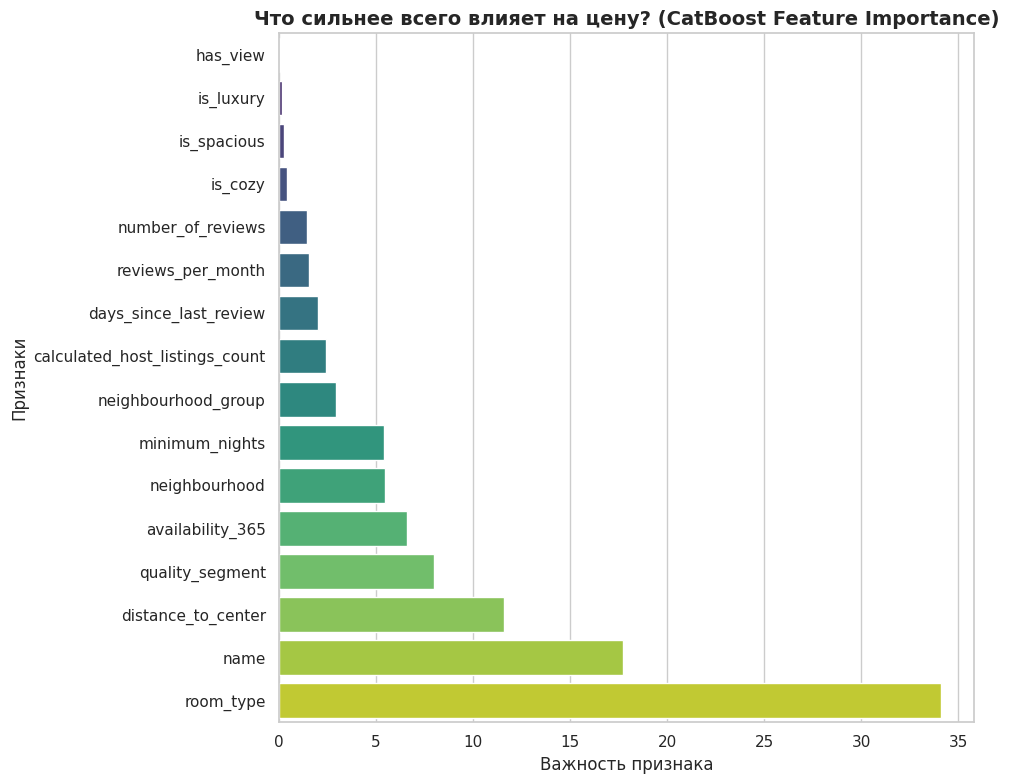

In [11]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cat_features =['neighbourhood_group', 'neighbourhood', 'room_type', 'quality_segment']
text_features = ['name']

X_train[cat_features] = X_train[cat_features].astype(str)
X_test[cat_features] = X_test[cat_features].astype(str)
X_train[text_features] = X_train[text_features].astype(str)
X_test[text_features] = X_test[text_features].astype(str)

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features,
    text_features=text_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features,
    text_features=text_features
)

cb_model = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    silent=True,
    random_seed=42
)

param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'iterations':[400, 600]
}

grid_search_result = cb_model.grid_search(
    param_grid,
    X=train_pool,
    cv=3,
    partition_random_seed=42,
    calc_cv_statistics=True,
    search_by_train_test_split=False,
    verbose=False
)

print(grid_search_result['params'])

preds_log = cb_model.predict(test_pool)

preds_real = np.expm1(preds_log)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, preds_real)
mape = mean_absolute_percentage_error(y_test_real, preds_real) * 100

print(f"Средняя ошибка (MAE): ${mae:.2f}")
print(f"Средняя ошибка в процентах (MAPE): {mape:.2f}%")

feature_importance = cb_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importance[sorted_idx], y=np.array(X_train.columns)[sorted_idx], palette="viridis")
plt.title('Что сильнее всего влияет на цену? (CatBoost Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Важность признака')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()